# Data Cleaning Section

In [1]:
import yfinance
import pandas as pd
import numpy as np

# Gerekli veriyi çekiyoruz
df = pd.read_csv("all_companies_balance_statements.csv")
df2 = pd.read_csv("all_companies_cashflow_statements.csv")
df3 = pd.read_csv("all_companies_income_statements.csv")
df4 = pd.read_excel("listof90year.xlsx")

# Prefixler ekleyerek verilerin ne olduğunu ekliyoruz
df_bs = df.add_prefix('bs_')
df_cf = df2.add_prefix('cf_')
df_is = df3.add_prefix('is_')
for col in ['symbol', 'calendarYear', 'period']:
    df_bs[col] = df[col]
    df_cf[col] = df2[col]
    df_is[col] = df3[col]

# Join key'leri ekleyip mergelüyoruz
combined_df = df_bs.merge(df_cf, on=['symbol', 'calendarYear', 'period'], how='outer')
combined_df = combined_df.merge(df_is, on=['symbol', 'calendarYear', 'period'], how='outer')

# combined_dfdeki boş rowları atıyorum ("bs_Symbol"'e göre)
cleaned_df = combined_df[combined_df['bs_Symbol'].notnull()]

In [2]:
# Hala boş valueları olanlar neler onu kontrol ediyorum
import pandas as pd
from tabulate import tabulate

missing_summary = cleaned_df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Column": missing_summary.index,
    "Missing Values": missing_summary.values,
    "Missing Rate (%)": (missing_summary.values / len(cleaned_df)) * 100
})
print(tabulate(missing_df, headers='keys', tablefmt='pretty'))
missing_columns = missing_df["Column"].tolist()
with open("missing_columns.txt", "w") as f:
    for col in missing_columns:
        f.write(col + "\n")
with open("columns.txt", "w") as f:
    for col in cleaned_df.columns:
        f.write(col + "\n")

+-----+---------------------------------------------+----------------+-----------------------+
|     |                   Column                    | Missing Values |   Missing Rate (%)    |
+-----+---------------------------------------------+----------------+-----------------------+
|  0  |                is_finalLink                 |     47318      |  31.528308046987956   |
|  1  |                   is_link                   |     47313      |   31.52497651268315   |
|  2  |                cf_finalLink                 |     47182      |   31.43769031389716   |
|  3  |                   cf_link                   |     47182      |   31.43769031389716   |
|  4  |                   bs_link                   |     47102      |  31.384385765020223   |
|  5  |                bs_finalLink                 |     47102      |  31.384385765020223   |
|  6  |                   cf_cik                    |      4478      |  2.9837221233867046   |
|  7  |        cf_effectOfForexChangesOnCash      

In [3]:
# Linklere metriklerde ihtiyaç olmayacağı için çıkarıp tekrar hataları çıkarıyorum
drop_cols = [
    "is_finalLink", "is_link",
    "cf_finalLink", "cf_link",
    "bs_link", "bs_finalLink"
]
filtered_missing_df = missing_df[~missing_df["Column"].isin(drop_cols)]
from tabulate import tabulate
print(tabulate(filtered_missing_df, headers='keys', tablefmt='pretty'))
filtered_columns = filtered_missing_df["Column"].tolist()
with open("filtered_missing_columns.txt", "w") as f:
    for col in filtered_columns:
        f.write(col + "\n")

+-----+---------------------------------------------+----------------+-----------------------+
|     |                   Column                    | Missing Values |   Missing Rate (%)    |
+-----+---------------------------------------------+----------------+-----------------------+
|  6  |                   cf_cik                    |      4478      |  2.9837221233867046   |
|  7  |        cf_effectOfForexChangesOnCash        |      4341      |   2.892438083434945   |
|  8  |          cf_stockBasedCompensation          |      4341      |   2.892438083434945   |
|  9  |             cf_netChangeInCash              |      4340      |  2.8917717765739837   |
| 10  |             cf_acquisitionsNet              |      4340      |  2.8917717765739837   |
| 11  |            cf_deferredIncomeTax             |      4340      |  2.8917717765739837   |
| 12  |          cf_commonStockRepurchased          |      4340      |  2.8917717765739837   |
| 13  |          cf_purchasesOfInvestments        

In [4]:
# CIK numarası dolduktan sonra nerelerde eksik olduğunu inceliyoruz
symbol_columns = [col for col in filtered_columns if "symbol" in col.lower()]
cik_columns = [col for col in filtered_columns if "cik" in col.lower()]
for col in symbol_columns:
    cleaned_df[col] = cleaned_df["is_Symbol"]
for col in cik_columns:
    cleaned_df[col] = cleaned_df["is_cik"]
missing_summary = cleaned_df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]
filtered_missing_df_updated = (
    pd.DataFrame({
        "Column": missing_summary.index,
        "Missing Values": missing_summary.values
    })
    .query("Column not in @drop_cols")
    .sort_values("Missing Values", ascending=False)
)
filtered_missing_df_updated["Missing Rate (%)"] = (
    filtered_missing_df_updated["Missing Values"] / len(cleaned_df) * 100
)
print(tabulate(filtered_missing_df_updated, headers='keys', tablefmt='pretty'))
with open("filtered_missing_columns.txt", "w") as f:
    for col in filtered_missing_df_updated["Column"]:
        f.write(col + "\n")

+-----+---------------------------------------------+----------------+-----------------------+
|     |                   Column                    | Missing Values |   Missing Rate (%)    |
+-----+---------------------------------------------+----------------+-----------------------+
| 36  |          cf_stockBasedCompensation          |      4341      |   2.892438083434945   |
| 56  |        cf_effectOfForexChangesOnCash        |      4341      |   2.892438083434945   |
| 57  |             cf_netChangeInCash              |      4340      |  2.8917717765739837   |
| 35  |            cf_deferredIncomeTax             |      4340      |  2.8917717765739837   |
| 45  |             cf_acquisitionsNet              |      4340      |  2.8917717765739837   |
| 52  |          cf_commonStockRepurchased          |      4340      |  2.8917717765739837   |
| 46  |          cf_purchasesOfInvestments          |      4339      |   2.891105469713022   |
| 47  |       cf_salesMaturitiesOfInvestments     

/var/folders/97/ch83kwyd58z8krz3tltkbxkm0000gn/T/ipykernel_959/1529254276.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df[col] = cleaned_df["is_Symbol"]
/var/folders/97/ch83kwyd58z8krz3tltkbxkm0000gn/T/ipykernel_959/1529254276.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df[col] = cleaned_df["is_cik"]


In [5]:
# Eğer boş hücresi varsa o satırı silen kod
columns_to_check = filtered_missing_df_updated["Column"].tolist()
cleaned_df.dropna(subset=columns_to_check, inplace=True)

/var/folders/97/ch83kwyd58z8krz3tltkbxkm0000gn/T/ipykernel_959/327273373.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df.dropna(subset=columns_to_check, inplace=True)


In [6]:
changed_df = cleaned_df

# Data Manipulation and Necessary Data Injection

## CIK Numbers - Ticker Matching

### Tickers who has more than one CIK Numbers

In [7]:
# Symbol başına CIK sayısını kontrol ediyoruz
cik_per_symbol = cleaned_df.groupby("symbol")["bs_cik"].nunique()
symbols_with_multiple_ciks = cik_per_symbol[cik_per_symbol > 1]
print(f"Birden fazla CIK'e sahip symbol sayısı: {len(symbols_with_multiple_ciks)}")
print(symbols_with_multiple_ciks.sort_values(ascending=False).head(45))

Birden fazla CIK'e sahip symbol sayısı: 45
symbol
ARRKF    2
ICTSF    2
IPHA     2
IRET     2
NBLWF    2
NE       2
NEWP     2
NUTR     2
NVAAF    2
OILCF    2
PAPL     2
PUBGY    2
QIPT     2
RR       2
SSL      2
TELO     2
TLN      2
TLSA     2
TSM      2
VSTS     2
WAY      2
INHD     2
IBACR    2
ASML     2
IBAC     2
BCH      2
BDC      2
BIDU     2
BKHA     2
BKHAR    2
BKHAU    2
BLK      2
BSAC     2
COOTW    2
CP       2
DRUG     2
EBBNF    2
EBGEF    2
ENB      2
ENGN     2
ENGNW    2
ENJ      2
GEV      2
GOVB     2
XPER     2
Name: bs_cik, dtype: int64


In [8]:
# Bir sembol birden fazla CIK'e sahipse, hangi CIK'ler olduğunu görelim
multi_cik_symbols = cik_per_symbol[cik_per_symbol > 1].index
for symbol in multi_cik_symbols:
    ciks = cleaned_df[cleaned_df["symbol"] == symbol]["bs_cik"].unique()
    print(f"{symbol}: {list(ciks)}")

ARRKF: [1855743.0, 0.0]
ASML: [0.0, 937966.0]
BCH: [0.0, 1161125.0]
BDC: [913142.0, 1896212.0]
BIDU: [0.0, 1329099.0]
BKHA: [0.0, 2000775.0]
BKHAR: [0.0, 2000775.0]
BKHAU: [0.0, 2000775.0]
BLK: [1364742.0, 2012383.0]
BSAC: [0.0, 1027552.0]
COOTW: [0.0, 1959994.0]
CP: [0.0, 16875.0]
DRUG: [0.0, 1827401.0]
EBBNF: [0.0, 895728.0]
EBGEF: [0.0, 895728.0]
ENB: [0.0, 895728.0]
ENGN: [0.0, 1100663.0]
ENGNW: [0.0, 1100663.0]
ENJ: [65984.0, 71508.0]
GEV: [0.0, 1996810.0]
GOVB: [0.0, 1978811.0]
IBAC: [0.0, 1998781.0]
IBACR: [0.0, 1998781.0]
ICTSF: [1010134.0, 0.0]
INHD: [0.0, 1961847.0]
IPHA: [0.0, 1598599.0]
IRET: [0.0, 798359.0]
NBLWF: [1895262.0, 1458891.0]
NE: [1895262.0, 1458891.0]
NEWP: [0.0, 1369085.0]
NUTR: [0.0, 105007.0]
NVAAF: [0.0, 1852551.0]
OILCF: [0.0, 1922639.0]
PAPL: [0.0, 1938109.0]
PUBGY: [1050952.0, 0.0]
QIPT: [0.0, 1540013.0]
RR: [0.0, 1963685.0]
SSL: [0.0, 314590.0]
TELO: [0.0, 1971532.0]
TLN: [0.0, 1622536.0]
TLSA: [0.0, 1723069.0]
TSM: [0.0, 1046179.0]
VSTS: [0.0, 1967649.

In [9]:
# 0.0 olanları diğerine eşitliyoruz
zero_cik_mask = cleaned_df["bs_cik"] == 0.0
symbols_with_zero_cik = cleaned_df[zero_cik_mask]["symbol"].unique()
for symbol in symbols_with_zero_cik:
    valid_ciks = cleaned_df[(cleaned_df["symbol"] == symbol) & (cleaned_df["bs_cik"] != 0.0)]["bs_cik"].unique()
    if len(valid_ciks) == 1:
        cleaned_df.loc[(cleaned_df["symbol"] == symbol) & (cleaned_df["bs_cik"] == 0.0), "bs_cik"] = valid_ciks[0]
remaining_zeros = cleaned_df[cleaned_df["bs_cik"] == 0.0]

In [11]:
# Symbol başına CIK sayısını tekrar kontrol ediyoruz
cik_per_symbol = cleaned_df.groupby("symbol")["bs_cik"].nunique()
symbols_with_multiple_ciks = cik_per_symbol[cik_per_symbol > 1]
multi_cik_symbols = cik_per_symbol[cik_per_symbol > 1].index
for symbol in multi_cik_symbols:
    ciks = cleaned_df[cleaned_df["symbol"] == symbol]["bs_cik"].unique()
    print(f"{symbol}: {list(ciks)}")

BDC: [913142.0, 1896212.0]
BLK: [1364742.0, 2012383.0]
ENJ: [65984.0, 71508.0]
NBLWF: [1895262.0, 1458891.0]
NE: [1895262.0, 1458891.0]
XPER: [1788999.0, 1803696.0]


In [ ]:
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen

import certifi
import json
import pandas as pd

def read_api_key_from_file(file_path):
    with open(file_path, "r") as file:
        return file.read().strip()

def get_jsonparsed_data(url):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

api_key = read_api_key_from_file("FMP API KEY.txt")

# cleaned_df içinde cik başına kaç symbol olduğunu kontrol et
cik_per_symbol = cleaned_df.groupby("symbol")["bs_cik"].nunique()
multi_cik_symbols = cik_per_symbol[cik_per_symbol > 1].index

# Sembolleri kontrol et
for symbol in multi_cik_symbols:
    ciks = cleaned_df[cleaned_df["symbol"] == symbol]["bs_cik"].unique()
    for cik in ciks:
        if cik == 0.0 or pd.isna(cik):
            continue  # Geçersiz cik'leri atla
        cik_str = str(int(cik)).zfill(10)  # CIK 10 haneli olmalı (FMP formatı)
        url = f"https://financialmodelingprep.com/api/v3/search-cik?cik={cik_str}&apikey={api_key}"
        try:
            response = get_jsonparsed_data(url)
            if response:
                for item in response:
                    fmp_symbol = item.get("symbol")
                    if fmp_symbol != symbol:
                        print(f"UYUMSUZLUK: Yerel symbol={symbol}, FMP'den gelen={fmp_symbol}, cik={cik_str}")
                    else:
                        print(f"✅ UYUMLU: {symbol} == {fmp_symbol}, cik={cik_str}")
            else:
                print(f"⚠️ CIK bulunamadı: {cik_str}")
        except Exception as e:
            print(f"❌ API hatası (cik={cik_str}): {e}")


/var/folders/97/ch83kwyd58z8krz3tltkbxkm0000gn/T/ipykernel_1064/2078923001.py:16: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


⚠️ CIK bulunamadı: 0000913142
⚠️ CIK bulunamadı: 0001896212
⚠️ CIK bulunamadı: 0001364742
⚠️ CIK bulunamadı: 0002012383
⚠️ CIK bulunamadı: 0000065984
⚠️ CIK bulunamadı: 0000071508
⚠️ CIK bulunamadı: 0001895262
⚠️ CIK bulunamadı: 0001458891
⚠️ CIK bulunamadı: 0001895262
⚠️ CIK bulunamadı: 0001458891
⚠️ CIK bulunamadı: 0001788999
⚠️ CIK bulunamadı: 0001803696


### Sorun


In [ ]:
try:
    from urllib.request import urlopen
except ImportError:
    from urllib2 import urlopen
import certifi
import json

def read_api_key_from_file(file_path):
    with open(file_path, "r") as file:
        return file.read().strip()

# JSON verisini çek
def get_jsonparsed_data(url):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

# API key'i dosyadan al
api_key = read_api_key_from_file("FMP API KEY.txt")
cik_number = 913142
# URL'yi dinamik olarak oluştur
url = f"https://financialmodelingprep.com/stable/search-cik?cik={cik_number}]&apikey={api_key}"

# Veriyi çek ve yazdır
print(get_jsonparsed_data(url))

/var/folders/97/ch83kwyd58z8krz3tltkbxkm0000gn/T/ipykernel_1064/2218418285.py:14: DeprecationWarning: cafile, capath and cadefault are deprecated, use a custom context instead.
  response = urlopen(url, cafile=certifi.where())


HTTPError: HTTP Error 400: Bad Request

In [ ]:
# CIK ve Symbollerin sayılarını kontrol ediyorum
symbol_per_cik = cleaned_df.groupby("bs_cik")["symbol"].nunique()
ciks_with_multiple_symbols = symbol_per_cik[symbol_per_cik > 1]
print(f"Birden fazla symbol'e sahip cik sayısı: {len(ciks_with_multiple_symbols)}")
print(ciks_with_multiple_symbols.sort_values(ascending=False).head(10))  # ilk 10 örnek

Birden fazla symbol'e sahip cik sayısı: 762
bs_cik
0.0          931
1026214.0     25
70858.0       17
310522.0      16
1393311.0     15
23426.0       13
1002910.0     12
895421.0      11
1464790.0      9
1004980.0      9
Name: bs_symbol, dtype: int64


In [ ]:
unique_symbols_with_zero_cik = cleaned_df[cleaned_df["bs_cik"] == 0.0]["bs_Symbol"].dropna().unique()
print(f"0.0 bs_cik değerine sahip unique bs_Symbol sayısı: {len(unique_symbols_with_zero_cik)}")
print(unique_symbols_with_zero_cik)

0.0 bs_cik değerine sahip unique bs_Symbol sayısı: 931
['AAMTF' 'AAUGF' 'ABAT' 'ABBNY' 'ABVE' 'ABVEW' 'ABVX' 'ABXXF' 'ACPS'
 'ACRL' 'ACZT' 'ADGM' 'ADIA' 'AERGP' 'AERS' 'AFJK' 'AFJKR' 'AFJKU' 'AFLYY'
 'AFRAF' 'AGQPF' 'AHL-PD' 'AHL-PE' 'AHRO' 'AIEV' 'AIJTY' 'AIOT' 'AIQUF'
 'AIQUY' 'AIRE' 'AIRJ' 'AIRJW' 'AITR' 'AITRR' 'AITRU' 'ALAB' 'ALMS'
 'ALSMY' 'ALYAF' 'AMIX' 'AMTM' 'AMX' 'ANL' 'ANSC' 'ANSCU' 'ANSCW' 'ANYYY'
 'AOAO' 'AOMFF' 'APHP' 'AQN' 'ARBK' 'ARBKF' 'ARDT' 'ARMN' 'ARRKF' 'ARTV'
 'ASII' 'ASML' 'ASR' 'ASX' 'ATGL' 'ATHE' 'ATLN' 'ATMH' 'ATPC' 'ATYR' 'AU'
 'AUNA' 'AVAI' 'AVBP' 'AVRW' 'AXREF' 'AYR' 'AYRWF' 'AZN' 'AZUL' 'BAFBF'
 'BAK' 'BAM' 'BAMXF' 'BAYA' 'BAYAR' 'BAYAU' 'BBAR' 'BBVA' 'BCAL' 'BCEPF'
 'BCG' 'BCGWW' 'BCH' 'BCPPF' 'BCUCF' 'BECEF' 'BEEP' 'BETRF' 'BETSF'
 'BEWFF' 'BGC' 'BHRB' 'BIDU' 'BIOA' 'BIOE' 'BIRK' 'BKAMF' 'BKFAF' 'BKFPF'
 'BKGFF' 'BKHA' 'BKHAR' 'BKHAU' 'BLFR' 'BLMH' 'BLMZ' 'BMA' 'BNAI' 'BNAIW'
 'BNIGF' 'BNPQF' 'BOLD' 'BOW' 'BP' 'BPTSY' 'BRENF' 'BRFS' 'BROXF' 'BRQSF'
 'BRR

In [8]:
unique_symbols_with_cik = cleaned_df[cleaned_df["bs_cik"] == 1026214.0]["bs_Symbol"].dropna().unique()
print(f"0.0 bs_cik değerine sahip unique bs_Symbol sayısı: {len(unique_symbols_with_cik)}")
print(unique_symbols_with_cik)

0.0 bs_cik değerine sahip unique bs_Symbol sayısı: 25
['FMCC' 'FMCCG' 'FMCCH' 'FMCCI' 'FMCCJ' 'FMCCK' 'FMCCL' 'FMCCM' 'FMCCN'
 'FMCCO' 'FMCCP' 'FMCCS' 'FMCCT' 'FMCKI' 'FMCKJ' 'FMCKK' 'FMCKL' 'FMCKM'
 'FMCKN' 'FMCKO' 'FMCKP' 'FREGP' 'FREJN' 'FREJO' 'FREJP']


## Currency Sorunu

In [ ]:
# Farklı currencyler var ama aynı satırda hepsi aynı mı onu kontrol ediyoruz
currency_match = (
    (cleaned_df["cf_reportedCurrency"] == cleaned_df["is_reportedCurrency"]) &
    (cleaned_df["cf_reportedCurrency"] == cleaned_df["bs_reportedCurrency"])
)
matching_currency_df = cleaned_df[currency_match]
mismatched_currency_df = cleaned_df[~currency_match]
print(f"Aynı currency olan satır sayısı: {currency_match.sum()} / {len(cleaned_df)}")


Aynı currency olan satır sayısı: 145303 / 145331


In [ ]:
import requests

def search_symbol_fmp(query, api_key, limit=10, exchange=None):
    base_url = "https://financialmodelingprep.com/api/v3/search"
    params = {
        "query": query,
        "limit": limit,
        "apikey": api_key
    }

    if exchange:
        params["exchange"] = exchange  

    response = requests.get(base_url, params=params)

    if response.status_code == 200:
        data = response.json()
        if data:
            print(f"🔍 {query} için bulunan {len(data)} sonuç:")
            for item in data:
                print(f"- Symbol: {item.get('symbol')}, Name: {item.get('name')}, Exchange: {item.get('stockExchange')}, Currency: {item.get('currency')}")
        else:
            print("❗ Sonuç bulunamadı.")
    else:
        print(f"❌ Hata: {response.status_code} - {response.text}")


api_key = ""  
search_symbol_fmp("AA", api_key)


🔍 AA için bulunan 10 sonuç:
- Symbol: AA, Name: Alcoa Corporation, Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAU, Name: Almaden Minerals Ltd., Exchange: AMEX, Currency: USD
- Symbol: AAT, Name: American Assets Trust, Inc., Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAP, Name: Advance Auto Parts, Inc., Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAN, Name: The Aaron's Company, Inc., Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAM, Name: AA Mission Acquisition Corp., Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAL, Name: American Airlines Group Inc., Exchange: NASDAQ Global Select, Currency: USD
- Symbol: AAC, Name: Ares Acquisition Corporation, Exchange: New York Stock Exchange, Currency: USD
- Symbol: AAA, Name: AXS First Priority CLO Bond ETF, Exchange: New York Stock Exchange Arca, Currency: USD
- Symbol: AAXT, Name: Aamaxan Transport Group, Inc., Exchange: Other OTC, Currency: USD


In [21]:
# Sadece NASDAQ içinde aramak istersen:
search_symbol_fmp("Tesla", api_key, limit=5, exchange="NASDAQ")


🔍 Tesla için bulunan 4 sonuç:
- Symbol: TSLA, Name: Tesla, Inc., Exchange: NASDAQ Global Select, Currency: USD
- Symbol: TSLT, Name: T-Rex 2X Long Tesla Daily Target ETF, Exchange: NASDAQ, Currency: USD
- Symbol: TSLZ, Name: T-Rex 2X Inverse Tesla Daily Target ETF, Exchange: NASDAQ, Currency: USD
- Symbol: TSL, Name: GraniteShares ETF Trust - GraniteShares 2x Long Tesla Daily ETF, Exchange: NASDAQ Global Market, Currency: USD


In [12]:
date_match = (
    (cleaned_df["cf_date"] == cleaned_df["is_date"]) &
    (cleaned_df["cf_date"] == cleaned_df["bs_date"])
)
matching_date_df = cleaned_df[date_match]
mismatched_date_df = cleaned_df[~date_match]

In [16]:
mismatched_date_df[["bs_date","is_date","cf_date"]]

,bs_date,is_date,cf_date
2135,2011-06-30,2012-06-30,2011-06-30
2136,2012-06-30,2012-12-31,2012-06-30
2211,2024-03-31,2023-12-31,2023-12-31
4880,2024-03-31,2023-03-31,2023-03-31
7529,2016-12-31,2016-09-30,2016-09-30
...,...,...,...
150943,2000-12-31,2000-04-29,2000-04-29
151198,2015-06-30,2014-12-31,2014-12-31
151201,2018-03-31,2017-12-31,2017-12-31
153121,2015-12-31,2015-12-31,2016-02-29


In [32]:
# Datada farklı currencylerle yazıldığını inceliyoruz
bs_currencies = cleaned_df["bs_reportedCurrency"].dropna().unique().tolist()
cleaned_df["cf_reportedCurrency"].dropna().unique().tolist()


['USD',
 'CNY',
 'CAD',
 'BRL',
 'EUR',
 'CHF',
 'JPY',
 'CLP',
 'HKD',
 'MXN',
 'MYR',
 'GBP',
 'ZAR',
 'TWD',
 'AUD',
 'PEN',
 'COP',
 'ARS',
 'THB',
 'ILS',
 'TRY',
 'SEK',
 'DKK',
 'KRW',
 'INR',
 'SGD',
 'PHP',
 'KZT',
 'NZD',
 'IDR',
 'NOK',
 'VND']

In [36]:
cleaned_df[cleaned_df["cf_reportedCurrency"] == "JPY"]

,bs_Symbol,bs_Unnamed: 1,bs_date,bs_symbol,bs_reportedCurrency,bs_cik,bs_fillingDate,bs_acceptedDate,bs_calendarYear,bs_period,...,is_incomeBeforeTaxRatio,is_incomeTaxExpense,is_netIncome,is_netIncomeRatio,is_eps,is_epsdiluted,is_weightedAverageShsOut,is_weightedAverageShsOutDil,is_link,is_finalLink
2392,ADTTF,22.0,2002-03-31,ADTTF,JPY,1158838.0,2002-08-20,2002-08-21 10:56:26,2001.0,FY,...,-0.404014,-1.453674e+10,-2.384495e+10,-0.250997,-119.22,-119.22,2.000000e+08,2.000000e+08,https://www.sec.gov/Archives/edgar/data/115883...,https://www.sec.gov/Archives/edgar/data/115883...
2393,ADTTF,21.0,2003-03-31,ADTTF,JPY,1158838.0,2003-06-30,2003-06-30 12:29:47,2002.0,FY,...,-0.191201,-5.588509e+09,-1.275326e+10,-0.132944,-65.72,-65.72,1.940547e+08,1.940547e+08,https://www.sec.gov/Archives/edgar/data/115883...,https://www.sec.gov/Archives/edgar/data/115883...
2394,ADTTF,20.0,2004-03-31,ADTTF,JPY,1158838.0,2004-06-29,2004-06-29 08:22:30,2003.0,FY,...,0.165758,1.139199e+10,1.709352e+10,0.099468,88.37,88.19,1.959116e+08,1.963011e+08,https://www.sec.gov/Archives/edgar/data/115883...,https://www.sec.gov/Archives/edgar/data/115883...
2395,ADTTF,19.0,2005-03-31,ADTTF,JPY,1158838.0,2005-07-26,2005-07-26 06:35:38,2004.0,FY,...,0.258137,2.369525e+10,3.802231e+10,0.159030,195.27,194.75,1.950992e+08,1.956164e+08,https://www.sec.gov/Archives/edgar/data/115883...,https://www.sec.gov/Archives/edgar/data/115883...
2396,ADTTF,18.0,2006-03-31,ADTTF,JPY,1158838.0,2006-06-28,2006-06-28 08:32:26,2005.0,FY,...,0.265648,2.613159e+10,4.145586e+10,0.162940,222.63,221.44,1.858232e+08,1.868194e+08,https://www.sec.gov/Archives/edgar/data/115883...,https://www.sec.gov/Archives/edgar/data/115883...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152406,YMHAY,4.0,2019-12-31,YMHAY,JPY,0.0,2019-12-31,2019-12-30 19:00:00,2019.0,FY,...,0.072458,3.657400e+10,7.573600e+10,0.045494,72.27,72.27,1.047895e+09,1.047895e+09,NaN,NaN
152407,YMHAY,3.0,2020-12-31,YMHAY,JPY,0.0,2020-12-31,2020-12-30 19:00:00,2020.0,FY,...,0.057765,2.921600e+10,5.307200e+10,0.036072,50.63,50.63,1.048202e+09,1.048202e+09,NaN,NaN
152408,YMHAY,2.0,2021-12-31,YMHAY,JPY,0.0,2021-12-31,2021-12-30 19:00:00,2021.0,FY,...,0.110182,3.557200e+10,1.555780e+11,0.085836,148.56,148.56,1.047271e+09,1.047271e+09,NaN,NaN
152409,YMHAY,1.0,2022-12-31,YMHAY,JPY,0.0,2022-12-31,2022-12-30 19:00:00,2022.0,FY,...,0.109319,5.621600e+10,1.744390e+11,0.077582,170.49,170.42,1.023159e+09,1.023588e+09,NaN,NaN


In [39]:
import requests
import pandas as pd

url = "https://api.exchangerate.host/timeseries"
params = {
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "base": "USD",
    "symbols": "JPY"
}

response = requests.get(url, params=params)
data = response.json()

data

{'success': False,
 'error': {'code': 101,
  'type': 'missing_access_key',
  'info': 'You have not supplied an API Access Key. [Required format: access_key=YOUR_ACCESS_KEY]'}}

In [28]:
cleaned_df[~cleaned_df["bs_reportedCurrency"].isin(["USD", "CNY", "CAD","BRL","EUR","CHF","JPY"])]


,bs_Symbol,bs_Unnamed: 1,bs_date,bs_symbol,bs_reportedCurrency,bs_cik,bs_fillingDate,bs_acceptedDate,bs_calendarYear,bs_period,...,is_incomeBeforeTaxRatio,is_incomeTaxExpense,is_netIncome,is_netIncomeRatio,is_eps,is_epsdiluted,is_weightedAverageShsOut,is_weightedAverageShsOutDil,is_link,is_finalLink
5364,AKO-A,25.0,1998-12-31,AKO-A,CLP,925261.0,1998-12-31,1998-12-30 19:00:00,1998.0,FY,...,0.131502,9.064469e+09,4.571013e+10,0.109740,344.16,344.16,126712000.0,126712000.0,NaN,NaN
5365,AKO-A,24.0,1999-12-31,AKO-A,CLP,925261.0,1999-12-31,1999-12-30 19:00:00,1999.0,FY,...,0.083780,5.091583e+09,2.715829e+10,0.070553,195.87,195.87,126712000.0,126712000.0,NaN,NaN
5366,AKO-A,23.0,2000-12-31,AKO-A,CLP,925261.0,2000-12-31,2000-12-30 19:00:00,2000.0,FY,...,0.074925,1.816256e+09,3.150029e+10,0.070841,248.54,248.54,126712000.0,126712000.0,NaN,NaN
5367,AKO-A,22.0,2001-12-31,AKO-A,CLP,925261.0,2002-07-01,2002-07-01 17:31:16,2001.0,FY,...,0.083576,7.210839e+09,3.306675e+10,0.068614,271.45,271.45,126713000.0,126713000.0,https://www.sec.gov/Archives/edgar/data/925261...,https://www.sec.gov/Archives/edgar/data/925261...
5368,AKO-A,21.0,2002-12-31,AKO-A,CLP,925261.0,2003-07-15,2003-07-15 17:27:25,2002.0,FY,...,0.104275,8.505043e+09,3.302161e+10,0.082918,263.18,263.18,126712000.0,126712000.0,https://www.sec.gov/Archives/edgar/data/925261...,https://www.sec.gov/Archives/edgar/data/925261...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152536,YTRA,4.0,2020-03-31,YTRA,INR,0.0,2020-03-31,2020-03-30 20:00:00,2020.0,FY,...,-0.097872,3.950000e+07,-6.985000e+08,-0.103738,-4.45,-4.45,156916193.0,156916193.0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
152537,YTRA,3.0,2021-03-31,YTRA,INR,0.0,2021-03-31,2021-03-30 20:00:00,2021.0,FY,...,-1.038137,6.630000e+07,-1.188630e+09,-1.099464,-7.57,-7.57,156916193.0,156916193.0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
152538,YTRA,2.0,2022-03-31,YTRA,INR,0.0,2022-03-31,2022-03-30 20:00:00,2022.0,FY,...,-0.161834,1.515000e+07,-3.078600e+08,-0.170211,-1.96,-1.96,156916193.0,156916193.0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...
152539,YTRA,1.0,2023-03-31,YTRA,INR,0.0,2023-03-31,2023-03-30 20:00:00,2023.0,FY,...,0.036031,4.546000e+07,7.634000e+07,0.022586,0.49,0.49,156916193.0,156916193.0,https://www.nseindia.com/companies-listing/cor...,https://www.nseindia.com/companies-listing/cor...


In [32]:
cleaned_df.loc[cleaned_df["cf_cik"].isnull(), "cf_cik"] = cleaned_df.loc[cleaned_df["cf_cik"].isnull(), "bs_cik"]
cleaned_df[cleaned_df["cf_cik"].isnull()][["is_Symbol", "is_cik","bs_Symbol", "bs_cik", "cf_Symbol","cf_cik"]]


,is_Symbol,is_cik,bs_Symbol,bs_cik,cf_Symbol,cf_cik
4856,AIOT,NaN,AIOT,NaN,AIOT,NaN
4857,AIOT,NaN,AIOT,NaN,AIOT,NaN
4858,AIOT,NaN,AIOT,NaN,AIOT,NaN
4859,AIOT,NaN,AIOT,NaN,AIOT,NaN
4860,AIOT,NaN,AIOT,NaN,AIOT,NaN
...,...,...,...,...,...,...
139942,UCB,NaN,UCB,NaN,UCB,NaN
139943,UCB,NaN,UCB,NaN,UCB,NaN
149997,WRD,NaN,WRD,NaN,WRD,NaN
149998,WRD,NaN,WRD,NaN,WRD,NaN


In [15]:
print("Eksik değer sayısı olan kolonlar:")
print(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])


Eksik değer sayısı olan kolonlar:
bs_cik                           180
bs_fillingDate                     1
bs_shortTermInvestments            6
bs_inventory                       2
bs_goodwill                        2
                               ...  
is_epsdiluted                    413
is_weightedAverageShsOut         412
is_weightedAverageShsOutDil      412
is_link                        47313
is_finalLink                   47318
Length: 105, dtype: int64


In [21]:
import pandas as pd

missing_summary = cleaned_df.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Column": missing_summary.index,
    "Missing Values": missing_summary.values,
    "Missing Rate (%)": (missing_summary.values / len(cleaned_df)) * 100
})

from tabulate import tabulate

print(tabulate(missing_df, headers='keys', tablefmt='pretty'))


+-----+---------------------------------------------+----------------+-----------------------+
|     |                   Column                    | Missing Values |   Missing Rate (%)    |
+-----+---------------------------------------------+----------------+-----------------------+
|  0  |                is_finalLink                 |     47318      |  31.528308046987956   |
|  1  |                   is_link                   |     47313      |   31.52497651268315   |
|  2  |                cf_finalLink                 |     47182      |   31.43769031389716   |
|  3  |                   cf_link                   |     47182      |   31.43769031389716   |
|  4  |                   bs_link                   |     47102      |  31.384385765020223   |
|  5  |                bs_finalLink                 |     47102      |  31.384385765020223   |
|  6  |                   cf_cik                    |      4478      |  2.9837221233867046   |
|  7  |        cf_effectOfForexChangesOnCash      

In [ ]:
pd.to_ cleaned_df.columns

Index(['bs_Symbol', 'bs_Unnamed: 1', 'bs_date', 'bs_symbol',
       'bs_reportedCurrency', 'bs_cik', 'bs_fillingDate', 'bs_acceptedDate',
       'bs_calendarYear', 'bs_period',
       ...
       'is_incomeBeforeTaxRatio', 'is_incomeTaxExpense', 'is_netIncome',
       'is_netIncomeRatio', 'is_eps', 'is_epsdiluted',
       'is_weightedAverageShsOut', 'is_weightedAverageShsOutDil', 'is_link',
       'is_finalLink'],
      dtype='object', length=141)


NameError: name 'combined_df' is not defined

In [ ]:
# sembolü değişenler için dict iht var
# df4 tickerları düzeltcek
a = pd.melt(df4,id_vars="year")[["year", "value"]].dropna()
len(a["value"].unique())
# bu yapılacak

In [ ]:
# Profitability Ratios
# Brüt Kâr Marjı
combined_df['gross_margin'] = combined_df['is_grossProfit'] / combined_df['is_revenue']

# Net Kâr Marjı
combined_df['net_margin'] = combined_df['is_netIncome'] / combined_df['is_revenue']

# Faaliyet Kâr Marjı (Operating Margin)
combined_df['operating_margin'] = combined_df['is_operatingIncome'] / combined_df['is_revenue']

# ROA - Return on Assets
combined_df['ROA'] = combined_df['is_netIncome'] / combined_df['bs_totalAssets']

# ROE - Return on Equity
combined_df['ROE'] = combined_df['is_netIncome'] / combined_df['bs_totalStockholdersEquity']

# EBITDA Marjı
combined_df['ebitda_margin'] = combined_df['is_ebitda'] / combined_df['is_revenue']

# Liquidity Ratios
# Cari Oran (Current Ratio)
combined_df['current_ratio'] = combined_df['bs_totalCurrentAssets'] / combined_df['bs_totalCurrentLiabilities']

# Asit Test Oranı (Quick Ratio)
combined_df['quick_ratio'] = (
    combined_df['bs_cashAndShortTermInvestments'] + combined_df['bs_netReceivables']
) / combined_df['bs_totalCurrentLiabilities']

# Efficiency Ratios
# Varlık Devir Hızı (Asset Turnover)
combined_df['asset_turnover'] = combined_df['is_revenue'] / combined_df['bs_totalAssets']

# Alacak Devir Hızı
combined_df['receivables_turnover'] = combined_df['is_revenue'] / combined_df['bs_netReceivables']

# Stok Devir Hızı
combined_df['inventory_turnover'] = combined_df['is_costOfRevenue'] / combined_df['bs_inventory']

# Leverage Ratios
# Borç/Özsermaye Oranı (Debt-to-Equity)
combined_df['debt_to_equity'] = combined_df['bs_totalLiabilities'] / combined_df['bs_totalStockholdersEquity']

# Borç/Varlık Oranı (Debt-to-Assets)
combined_df['debt_to_assets'] = combined_df['bs_totalLiabilities'] / combined_df['bs_totalAssets']

# Uzun Vadeli Borç / Özsermaye
combined_df['longterm_debt_to_equity'] = combined_df['bs_longTermDebt'] / combined_df['bs_totalStockholdersEquity']

# Cash Flow Ratios
# Faaliyet Nakit Akışı / Net Gelir
combined_df['operating_cf_to_netincome'] = combined_df['cf_operatingCashFlow'] / combined_df['is_netIncome']

# Serbest Nakit Akışı / Toplam Varlık
combined_df['free_cf_to_assets'] = combined_df['cf_freeCashFlow'] / combined_df['bs_totalAssets']

# Serbest Nakit Akışı / Özsermaye
combined_df['free_cf_to_equity'] = combined_df['cf_freeCashFlow'] / combined_df['bs_totalStockholdersEquity']

ratio_cols = [col for col in combined_df.columns if any(x in col for x in ['margin', 'ratio', 'ROA', 'ROE', 'turnover', 'debt_', 'cf_'])]
for col in ratio_cols:
    combined_df[col] = combined_df[col].replace([np.inf, -np.inf], np.nan)

# rajan zingales index 2008 mendoza terrones makalesi
# tobins q
# apandix 3 https://www.imf.org/external/np/seminars/eng/2008/fincycl/pdf/mete.pdf üstü b microeceonomic and financial data
# https://aiasci.github.io/credit/#effect-of-credit-booms-on-private-non-financial-sector



In [53]:
# Kullanılacak oran sütunları (senin verdiğin oranlara göre seçildi)
ranking_metrics = [
    'gross_margin', 'net_margin', 'operating_margin', 'ROA', 'ROE', 'ebitda_margin',
    'current_ratio', 'quick_ratio',
    'asset_turnover', 'receivables_turnover', 'inventory_turnover',
    'debt_to_equity', 'debt_to_assets', 'longterm_debt_to_equity',
    'operating_cf_to_netincome', 'free_cf_to_assets', 'free_cf_to_equity'
]

ranked_results = []

for idx, row in df4.iterrows():
    year = row['year']
    prev_year = year - 1
    tickers = row[1:].dropna().unique().tolist()

    df_year = combined_df[
        (combined_df['calendarYear'].astype(int) == prev_year) &
        (combined_df['symbol'].isin(tickers))
    ].copy()

    if df_year.empty:
        continue

    # Her metriği sıralayıp 'rank_' önekiyle yeni sütun olarak ekle
    for metric in ranking_metrics:
        if metric in df_year.columns:
            df_year[f"rank_{metric}"] = df_year[metric].rank(ascending=False, method='min')

    # Tüm rank sütunlarını topla
    rank_cols = [col for col in df_year.columns if col.startswith('rank_')]
    df_year['combined_score'] = df_year[rank_cols].sum(axis=1)

    # Toplam skor üzerinden final sıralama
    df_year['final_rank'] = df_year['combined_score'].rank(method='min')
    df_year['ranking_year'] = year

    ranked_results.append(df_year)

# Tüm yıl verilerini birleştir
ranked_df = pd.concat(ranked_results, ignore_index=True)
ranked_df = ranked_df.sort_values(by=['ranking_year', 'final_rank'])

# Sonuç
print("Sıralanmış toplam gözlem:", ranked_df.shape)


Sıralanmış toplam gözlem: (9814, 182)


In [54]:
ranked_df.groupby('ranking_year').head(5)[['ranking_year', 'symbol', 'final_rank']]


,ranking_year,symbol,final_rank
142,2000,EFX,1.0
212,2000,FLR,2.0
137,2000,GIS,3.0
195,2000,CPB,4.0
71,2000,MO,5.0
...,...,...,...
9492,2025,MA,1.0
9550,2025,COP,2.0
9498,2025,JNJ,3.0
9570,2025,MCO,4.0


[[1909    2]
 [  34   18]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1911
           1       0.90      0.35      0.50        52

    accuracy                           0.98      1963
   macro avg       0.94      0.67      0.75      1963
weighted avg       0.98      0.98      0.98      1963



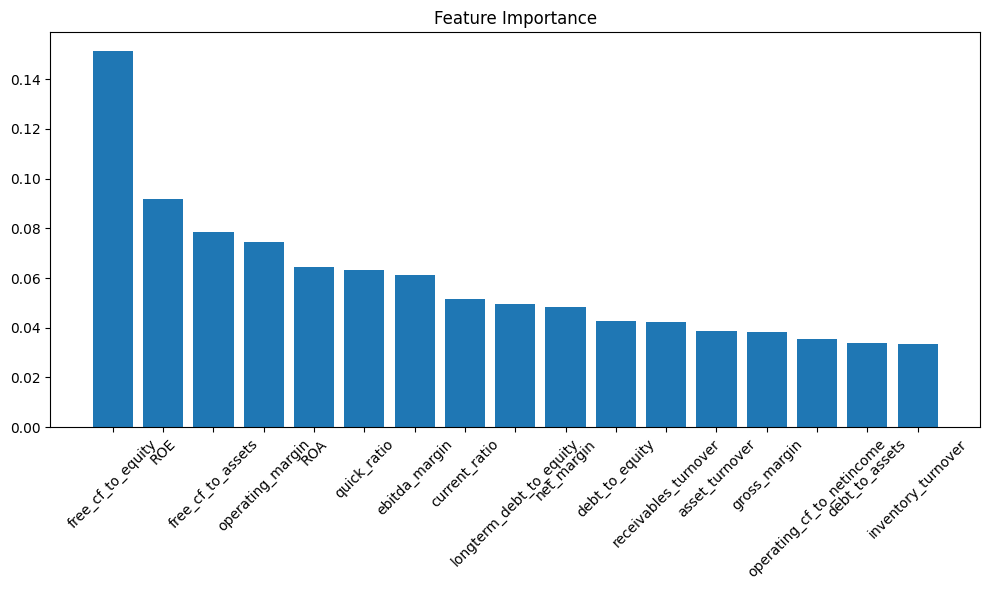

In [55]:
# Yeni hedef sütun
ranked_df['top10'] = (ranked_df['final_rank'] <= 10).astype(int)
# Özellikler (rasyolar)
X = ranked_df[ranking_metrics]

# Hedef değişken (ilk 10'a girme)
y = ranked_df['top10']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Performans değerlendirmesi
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [feat_names[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


In [57]:
# Özellik önemlerini pandas serisine çevir
importances = pd.Series(model.feature_importances_, index=ranking_metrics)

# Normalize edelim ki toplam 1 olsun (ağırlık toplamı)
weights = importances / importances.sum()
weighted_ranked_results = []

for idx, row in df4.iterrows():
    year = row['year']
    prev_year = year - 1
    tickers = row[1:].dropna().unique().tolist()

    df_year = combined_df[
        (combined_df['calendarYear'].astype(int) == prev_year) &
        (combined_df['symbol'].isin(tickers))
    ].copy()

    if df_year.empty:
        continue

    # Her metriğin sıralamasını hesapla
    for metric in ranking_metrics:
        if metric in df_year.columns:
            df_year[f"rank_{metric}"] = df_year[metric].rank(ascending=False, method='min')

    # Ağırlıklı toplam skoru hesapla
    weighted_score = 0
    for metric in ranking_metrics:
        rank_col = f"rank_{metric}"
        if rank_col in df_year.columns:
            weighted_score += df_year[rank_col] * weights[metric]

    df_year['weighted_score'] = weighted_score

    # Final sıralama
    df_year['final_weighted_rank'] = df_year['weighted_score'].rank(method='min')
    df_year['ranking_year'] = year

    weighted_ranked_results.append(df_year)

# Tüm yılları birleştir
weighted_ranked_df = pd.concat(weighted_ranked_results, ignore_index=True)
weighted_ranked_df = weighted_ranked_df.sort_values(by=['ranking_year', 'final_weighted_rank'])


In [62]:
# İlk 5 firmayı yıl bazlı karşılaştıralım
comparison = weighted_ranked_df.groupby('ranking_year').head(5)[
    ['ranking_year', 'symbol', 'final_weighted_rank']
]
comparison[comparison["ranking_year"]==2000]

,ranking_year,symbol,final_weighted_rank
25,2000,ADBE,1.0
3,2000,LLY,2.0
195,2000,CPB,3.0
71,2000,MO,4.0
137,2000,GIS,5.0


In [67]:
import yfinance as yf
import pandas as pd

def calculate_strategy_returns(ranked_df, rank_column='final_rank', top_n=20):
    portfolio_returns = []

    for year in range(2000, 2024):
        buy_date = f"{year}-04-01"
        sell_date = f"{year+1}-03-30"

        top = ranked_df[ranked_df['ranking_year'] == year].nsmallest(top_n, rank_column)
        tickers = top['symbol'].dropna().unique().tolist()

        if not tickers:
            continue

        try:
            # Verileri çek
            data = yf.download(tickers, start=buy_date, end=sell_date, progress=False)['Adj Close']

            # Tek sembolse Series olarak gelir → DataFrame yap
            if isinstance(data, pd.Series):
                data = data.to_frame()

            data = data.ffill().bfill()

            # En yakın tarihleri belirle
            buy_date_actual = min(data.index, key=lambda d: abs(pd.Timestamp(buy_date) - d))
            sell_date_actual = min(data.index, key=lambda d: abs(pd.Timestamp(sell_date) - d))

            # Fiyatları al
            buy_prices = data.loc[buy_date_actual]
            sell_prices = data.loc[sell_date_actual]

            # Return hesapla
            returns = (sell_prices / buy_prices) - 1
            avg_return = returns.mean()

            portfolio_returns.append({
                'year': year,
                'buy_date': str(buy_date_actual.date()),
                'sell_date': str(sell_date_actual.date()),
                'average_return': avg_return,
                'tickers': tickers
            })

        except Exception as e:
            print(f"{year} için veri alınamadı: {e}")
            continue

    return pd.DataFrame(portfolio_returns)


In [70]:
def download_prices_safe(tickers, start, end):
    collected_data = {}

    for ticker in tickers:
        try:
            df = yf.download(ticker, start=start, end=end, progress=False)['Adj Close']
            if not df.empty:
                collected_data[ticker] = df
        except Exception as e:
            print(f"Failed to get {ticker}: {e}")
            continue

    return pd.DataFrame(collected_data)
def calculate_strategy_returns(ranked_df, rank_column='final_rank', top_n=20):
    portfolio_returns = []

    for year in range(2000, 2024):
        buy_date = f"{year}-04-01"
        sell_date = f"{year+1}-03-30"

        top = ranked_df[ranked_df['ranking_year'] == year].nsmallest(top_n, rank_column)
        tickers = top['symbol'].dropna().unique().tolist()

        if not tickers:
            continue

        try:
            price_data = download_prices_safe(tickers, buy_date, sell_date)

            if price_data.empty:
                print(f"{year} için hiç veri bulunamadı.")
                continue

            price_data = price_data.ffill().bfill()

            buy_date_actual = min(price_data.index, key=lambda d: abs(pd.Timestamp(buy_date) - d))
            sell_date_actual = min(price_data.index, key=lambda d: abs(pd.Timestamp(sell_date) - d))

            buy_prices = price_data.loc[buy_date_actual]
            sell_prices = price_data.loc[sell_date_actual]

            returns = (sell_prices / buy_prices) - 1
            avg_return = returns.mean()

            portfolio_returns.append({
                'year': year,
                'buy_date': str(buy_date_actual.date()),
                'sell_date': str(sell_date_actual.date()),
                'average_return': avg_return,
                'tickers_used': list(price_data.columns)
            })

        except Exception as e:
            print(f"{year} için genel hata: {e}")
            continue

    return pd.DataFrame(portfolio_returns)


In [71]:
# Klasik sıralama ile getiri
classic_results = calculate_strategy_returns(ranked_df, rank_column='final_rank')

# RF ağırlıklı sıralama ile getiri
rf_results = calculate_strategy_returns(weighted_ranked_df, rank_column='final_weighted_rank')



1 Failed download:
['EFX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'FLR' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['FLR']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['GIS']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CPB']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['MO']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['ADBE']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['LLY']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['MSFT']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['TROW']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get t

2000 için hiç veri bulunamadı.



1 Failed download:
['CPB']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['EFX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['USB']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'CAR' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['CAR']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['PNC']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['ADBE']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'DLX' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['DLX']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'SLM' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['SLM']: YFTzMi

2001 için hiç veri bulunamadı.


Failed to get ticker 'PLL' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['PLL']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['EFX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['ZBH']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'DLX' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['DLX']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['YUM']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['GIS']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'PCG' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['PCG']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
Failed to get ticker 'SLM' re

...

2011 için hiç veri bulunamadı.


Failed to get ticker 'TRIP' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['TRIP']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['PM']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['AXP']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['UPS']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['GILD']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['BKNG']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['WU']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['WYNN']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CF']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['MCD']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed down

2012 için hiç veri bulunamadı.



1 Failed download:
['MCO']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['ABBV']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['BKNG']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['CL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['AFL']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')
Failed to get ticker 'TRIP' reason: Expecting value: line 1 column 1 (char 0)

1 Failed download:
['TRIP']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')

1 Failed download:
['HSY']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['MO']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['WU']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed download:
['AXP']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')

1 Failed downl

KeyboardInterrupt: 

In [65]:
summary_df = pd.DataFrame({
    'year': classic_results['year'],
    'classic_avg_return': classic_results['average_return'].values,
    'rf_weighted_avg_return': rf_weighted_results['average_return'].values
})

summary_df['difference'] = summary_df['rf_weighted_avg_return'] - summary_df['classic_avg_return']
print(summary_df)

print("\nOrtalama Getiri (Classic):", summary_df['classic_avg_return'].mean())
print("Ortalama Getiri (RF Weighted):", summary_df['rf_weighted_avg_return'].mean())
print("Ortalama Getiri Farkı:", summary_df['difference'].mean())


KeyError: 'year'